<a href="https://colab.research.google.com/github/Sayak-coder/SIH_26051/blob/main/Solar_calculationipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
!pip install pvlib

In [54]:
from pvlib.location import lookup_altitude
altitude=lookup_altitude(latitude=34.19017158279835, longitude=77.59516659195025)
altitude

4702.0

In [55]:
import pandas as pd
times=pd.date_range(start='2020-01-01 00:00', end='2025-12-31 23:59', freq='1h', tz='Asia/Kolkata')
times

DatetimeIndex(['2020-01-01 00:00:00+05:30', '2020-01-01 01:00:00+05:30',
               '2020-01-01 02:00:00+05:30', '2020-01-01 03:00:00+05:30',
               '2020-01-01 04:00:00+05:30', '2020-01-01 05:00:00+05:30',
               '2020-01-01 06:00:00+05:30', '2020-01-01 07:00:00+05:30',
               '2020-01-01 08:00:00+05:30', '2020-01-01 09:00:00+05:30',
               ...
               '2025-12-31 14:00:00+05:30', '2025-12-31 15:00:00+05:30',
               '2025-12-31 16:00:00+05:30', '2025-12-31 17:00:00+05:30',
               '2025-12-31 18:00:00+05:30', '2025-12-31 19:00:00+05:30',
               '2025-12-31 20:00:00+05:30', '2025-12-31 21:00:00+05:30',
               '2025-12-31 22:00:00+05:30', '2025-12-31 23:00:00+05:30'],
              dtype='datetime64[ns, Asia/Kolkata]', length=52608, freq='h')

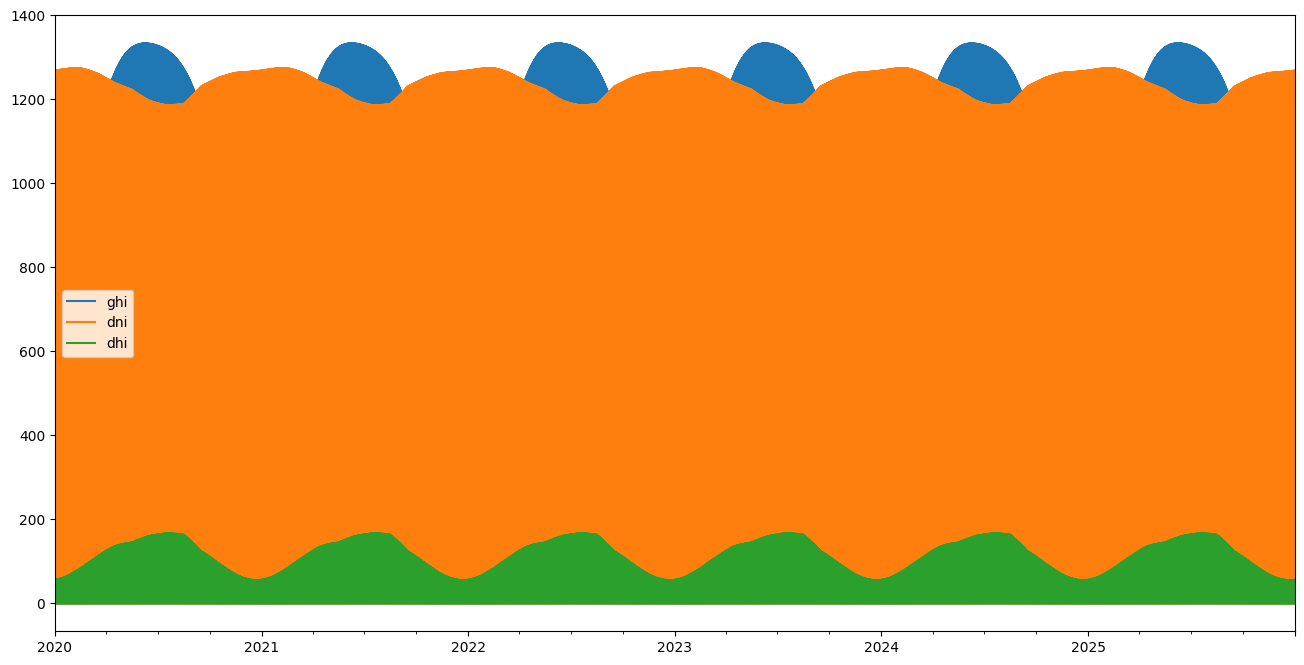

In [56]:
import matplotlib.pyplot as plt
from pvlib.location import Location
location = Location(latitude=34.19017158279835, longitude=77.59516659195025, tz='Asia/Kolkata', altitude=altitude)
clearsky=location.get_clearsky(times=times)
clearsky.plot(figsize=(16,8))
plt.show()

In [57]:
from pvlib.solarposition import get_solarposition
solar_position=get_solarposition(time=times,latitude=34.19017158279835, longitude=77.59516659195025, altitude=altitude)
solar_position

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
2020-01-01 00:00:00+05:30,167.836988,167.836988,-77.836988,-77.836988,334.547026,-2.972316
2020-01-01 01:00:00+05:30,166.200180,166.200180,-76.200180,-76.200180,38.781307,-2.992228
2020-01-01 02:00:00+05:30,156.005060,156.005060,-66.005060,-66.005060,68.822897,-3.012131
2020-01-01 03:00:00+05:30,143.979414,143.979414,-53.979414,-53.979414,82.595724,-3.032026
2020-01-01 04:00:00+05:30,131.600947,131.600947,-41.600947,-41.600947,91.729722,-3.051912
...,...,...,...,...,...,...
2025-12-31 19:00:00+05:30,110.075817,110.075817,-20.075817,-20.075817,255.182574,-3.120076
2025-12-31 20:00:00+05:30,122.233717,122.233717,-32.233717,-32.233717,262.460837,-3.139804
2025-12-31 21:00:00+05:30,134.599945,134.599945,-44.599945,-44.599945,270.301203,-3.159523
2025-12-31 22:00:00+05:30,146.940172,146.940172,-56.940172,-56.940172,280.153439,-3.179233


In [58]:
surface_azimuth,surface_tilt,albedo= 180.0,46.0,0.20
from pvlib.irradiance import get_extra_radiation
dni_extra = get_extra_radiation(times)
dni_extra

,0
2020-01-01 00:00:00+05:30,1413.940576
2020-01-01 01:00:00+05:30,1413.940576
2020-01-01 02:00:00+05:30,1413.940576
2020-01-01 03:00:00+05:30,1413.940576
2020-01-01 04:00:00+05:30,1413.940576
...,...
2025-12-31 19:00:00+05:30,1413.940576
2025-12-31 20:00:00+05:30,1413.940576
2025-12-31 21:00:00+05:30,1413.940576
2025-12-31 22:00:00+05:30,1413.940576


In [59]:
from pvlib.irradiance import get_total_irradiance
total_irrad_haydavies=get_total_irradiance(
    surface_tilt=surface_tilt,
    surface_azimuth=surface_azimuth,
    solar_zenith=solar_position['zenith'],
    solar_azimuth=solar_position['azimuth'],
    dni=clearsky['dni'],
    ghi=clearsky['ghi'],
    dhi=clearsky['dhi'],
    dni_extra=dni_extra,
    model='haydavies',
    albedo=albedo
)

total_irrad_haydavies

,poa_global,poa_direct,poa_diffuse,poa_sky_diffuse,poa_ground_diffuse
2020-01-01 00:00:00+05:30,0.0,0.0,0.0,0.0,0.0
2020-01-01 01:00:00+05:30,0.0,0.0,0.0,0.0,0.0
2020-01-01 02:00:00+05:30,0.0,0.0,0.0,0.0,0.0
2020-01-01 03:00:00+05:30,0.0,0.0,0.0,0.0,0.0
2020-01-01 04:00:00+05:30,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
2025-12-31 19:00:00+05:30,0.0,0.0,0.0,0.0,0.0
2025-12-31 20:00:00+05:30,0.0,0.0,0.0,0.0,0.0
2025-12-31 21:00:00+05:30,0.0,0.0,0.0,0.0,0.0
2025-12-31 22:00:00+05:30,0.0,0.0,0.0,0.0,0.0


In [60]:
from pvlib.atmosphere import get_relative_airmass
airmass=get_relative_airmass(solar_position['apparent_zenith'])
airmass

,0
2020-01-01 00:00:00+05:30,NaN
2020-01-01 01:00:00+05:30,NaN
2020-01-01 02:00:00+05:30,NaN
2020-01-01 03:00:00+05:30,NaN
2020-01-01 04:00:00+05:30,NaN
...,...
2025-12-31 19:00:00+05:30,NaN
2025-12-31 20:00:00+05:30,NaN
2025-12-31 21:00:00+05:30,NaN
2025-12-31 22:00:00+05:30,NaN


In [61]:
from pvlib.irradiance import perez
total_irrad_perez=perez(
    surface_tilt=surface_tilt,
    surface_azimuth=surface_azimuth,
    dhi=clearsky['dhi'],
    dni=clearsky['dni'],
    dni_extra=dni_extra,
    solar_zenith=solar_position['apparent_zenith'],
    solar_azimuth=solar_position['azimuth'],
    airmass=airmass,
    model='allsitescomposite1990')
total_irrad_perez

,0
2020-01-01 00:00:00+05:30,0.0
2020-01-01 01:00:00+05:30,0.0
2020-01-01 02:00:00+05:30,0.0
2020-01-01 03:00:00+05:30,0.0
2020-01-01 04:00:00+05:30,0.0
...,...
2025-12-31 19:00:00+05:30,0.0
2025-12-31 20:00:00+05:30,0.0
2025-12-31 21:00:00+05:30,0.0
2025-12-31 22:00:00+05:30,0.0


In [62]:
from pvlib.irradiance import get_ground_diffuse
poa_ground = get_ground_diffuse(surface_tilt=surface_tilt, ghi=clearsky['ghi'], albedo=albedo)
poa_ground

,diffuse_ground
2020-01-01 00:00:00+05:30,0.0
2020-01-01 01:00:00+05:30,0.0
2020-01-01 02:00:00+05:30,0.0
2020-01-01 03:00:00+05:30,0.0
2020-01-01 04:00:00+05:30,0.0
...,...
2025-12-31 19:00:00+05:30,0.0
2025-12-31 20:00:00+05:30,0.0
2025-12-31 21:00:00+05:30,0.0
2025-12-31 22:00:00+05:30,0.0


In [63]:
from pvlib.irradiance import aoi
aoi=aoi(surface_tilt=surface_tilt, surface_azimuth=surface_azimuth, solar_zenith=solar_position['apparent_zenith'], solar_azimuth=solar_position['azimuth'])
aoi

,aoi
2020-01-01 00:00:00+05:30,144.677883
2020-01-01 01:00:00+05:30,143.936435
2020-01-01 02:00:00+05:30,137.757127
2020-01-01 03:00:00+05:30,128.050729
2020-01-01 04:00:00+05:30,116.421656
...,...
2025-12-31 19:00:00+05:30,93.765019
2025-12-31 20:00:00+05:30,106.898587
2025-12-31 21:00:00+05:30,119.370070
2025-12-31 22:00:00+05:30,130.644985


In [64]:
import numpy as np
dni=clearsky['dni']
poa_direct = np.maximum(dni * np.cos(np.radians(aoi)), 0.0)
poa_perez_total = poa_direct + total_irrad_perez + poa_ground

In [65]:
poa_global = total_irrad_haydavies["poa_global"]

In [66]:
np.dtype(poa_global)

dtype('float64')

In [67]:
surface_absorptivity=float(input('Enter surface absorptivity value: '))
glazing_shgc=float(input('Enter glazing shgc value: '))
surface_area=float(input('Enter surface area value: '))

poa_global = total_irrad_haydavies["poa_global"]

q_gain_opaque = poa_global * surface_absorptivity * surface_area
q_gain_glazing = poa_global * glazing_shgc * surface_area
print(q_gain_opaque)
print(q_gain_opaque)

Enter surface absorptivity value: 0.65
Enter glazing shgc value: 0.40
Enter surface area value: 25.0
2020-01-01 00:00:00+05:30    0.0
2020-01-01 01:00:00+05:30    0.0
2020-01-01 02:00:00+05:30    0.0
2020-01-01 03:00:00+05:30    0.0
2020-01-01 04:00:00+05:30    0.0
                            ... 
2025-12-31 19:00:00+05:30    0.0
2025-12-31 20:00:00+05:30    0.0
2025-12-31 21:00:00+05:30    0.0
2025-12-31 22:00:00+05:30    0.0
2025-12-31 23:00:00+05:30    0.0
Freq: h, Name: poa_global, Length: 52608, dtype: float64
2020-01-01 00:00:00+05:30    0.0
2020-01-01 01:00:00+05:30    0.0
2020-01-01 02:00:00+05:30    0.0
2020-01-01 03:00:00+05:30    0.0
2020-01-01 04:00:00+05:30    0.0
                            ... 
2025-12-31 19:00:00+05:30    0.0
2025-12-31 20:00:00+05:30    0.0
2025-12-31 21:00:00+05:30    0.0
2025-12-31 22:00:00+05:30    0.0
2025-12-31 23:00:00+05:30    0.0
Freq: h, Name: poa_global, Length: 52608, dtype: float64


In [71]:
q_gain_opaque.unique()

array([    0.        ,  5768.47862902, 12789.88917689, ...,
       16509.0578385 , 11363.52816921,  3340.11612051])